In [1]:
import diplib as dip
#from diplib import MeasurementTool  # for measurement (we use manual measurement here)
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

DIPlib -- a quantitative image analysis library
Version 3.5.2 (Dec 27 2024)
For more information see https://diplib.org


# Helper functions

In [2]:
# --- Helper function: Convert DIPLib image to NumPy array ---
def to_numpy(dip_img):
    try:
        return np.array(dip_img)
    except Exception as e:
        print("Error converting DIPLib image to numpy array:", e)
        return None
    
# --- Helper function: Compute approximate perimeter from a binary mask ---
def compute_perimeter(mask):
    """
    Approximate perimeter for a binary mask using an 8-connected method.
    Counts object pixels with at least one background neighbor.
    """
    padded = np.pad(mask, pad_width=1, mode='constant', constant_values=False)
    shifts = [
        padded[0:-2, 0:-2],
        padded[0:-2, 1:-1],
        padded[0:-2, 2:],
        padded[1:-1, 0:-2],
        padded[1:-1, 2:],
        padded[2:, 0:-2],
        padded[2:, 1:-1],
        padded[2:, 2:]
    ]
    center = padded[1:-1, 1:-1]
    boundary = np.zeros_like(center, dtype=bool)
    for nbr in shifts:
        boundary |= (~nbr)
    boundary = center & boundary
    return np.sum(boundary)

# --- Helper function: Compute area and perimeter measurements from labeled array ---
def compute_measurements(labeled_array):
    labels = np.unique(labeled_array)
    labels = labels[labels != 0]  # ignore background
    areas = []
    perims = []
    for lbl in labels:
        mask = (labeled_array == lbl)
        area = np.sum(mask)
        perim = compute_perimeter(mask)
        areas.append(area)
        perims.append(perim)
    return np.array(areas), np.array(perims)

# --- Helper function: Contrast Stretching ---
def contrast_stretch_image(img, new_min=0, new_max=255):
    img_np = to_numpy(img)
    if img_np is None:
        return img
    curr_min = img_np.min()
    curr_max = img_np.max()
    if curr_min == curr_max:
        return img
    scale = (new_max - new_min) / (curr_max - curr_min)
    try:
        stretched = dip.ContrastStretch(img, curr_min, curr_max, new_min, new_max)
        return stretched
    except Exception as e:
        print("ContrastStretch failed, falling back to numpy scaling:", e)
        img_np_scaled = ((img_np - curr_min) * scale + new_min).astype(np.uint8)
        return img_np_scaled
    


# Processing pipeline

In [3]:
# Proceccing pipeline for image series

def processing_pipeline(series, outdir, nBins, apply_contrast_stretch, remove_edge_objects, max_fg_fraction,
                        fixed_threshold_value, apply_denoising, kernel_size=(5,10), kernel_shape='elliptic'):
    # Dictionaries to store measurement results.
    area_results = {}
    perim_results = {}

    # Lists for relative discretization error plots (Question 2.2).
    sqrt_mean_areas_list = []
    cv_area_list = []
    sqrt_mean_perim_list = []
    cv_perim_list = []
    image_names = []

    for image_file in series:
        if not os.path.exists(image_file):
            print(f"File not found: {image_file}")
            continue

        print(f"\nProcessing {os.path.basename(image_file)} for measurements...")
        
        # 1. Load the image.
        img = dip.ImageReadTIFF(image_file)
        img_np = to_numpy(img)
        if img_np is None:
            continue
        orig_min, orig_max = img_np.min(), img_np.max()
        print(f"Original intensity range: min = {orig_min}  max = {orig_max}")

        # Compute and Save Histogram.
        hist_obj = dip.Histogram(img, nBins=nBins)
        try:
            hist_values = np.array([hist_obj[i] for i in range(nBins)])
        except Exception as e:
            print(f"Error extracting histogram for {os.path.basename(image_file)}: {e}")
            continue
        bins = np.linspace(0, 255, num=nBins)
        plt.figure()
        plt.bar(bins, hist_values, width=(255/nBins), edgecolor='black')
        plt.title("Histogram of " + os.path.basename(image_file))
        plt.xlabel("Intensity")
        plt.ylabel("Frequency")
        plt.grid(True)
        hist_filename = os.path.join(outdir, os.path.basename(image_file) + "_hist.png")
        plt.savefig(hist_filename)
        plt.close()
        print(f"Histogram saved as {hist_filename}")

        # Apply median filter before segmentation
        if apply_denoising:
            print("Applying denoissing using mean filter")
            k = dip.Kernel(param =[kernel_size[0] ,kernel_size[0]],shape = kernel_shape)
            img = dip.MedianFilter(img, kernel=k)
            # Save denoised image.
            denoised_np = to_numpy(img)
            plt.figure()
            plt.imshow(denoised_np, cmap='gray')
            plt.title("Median Filter (kernel size: {kernel_size}, kernal shape {kernel_shape}) - " + os.path.basename(image_file))
            plt.axis('off')
            denoised_filename = os.path.join(outdir, os.path.basename(image_file) + f"_denoised_ksize_{kernel_size}_kshape_{kernel_shape}.png")
            plt.savefig(denoised_filename, bbox_inches='tight')
            plt.close()
            print(f"Denoised image saved as {denoised_filename}")


        
        # 2. Optionally apply contrast stretching.
        if apply_contrast_stretch:
            print("Applying contrast stretching to map intensity range to 0-255.")
            img = contrast_stretch_image(img, 0, 255)
            img_np = to_numpy(img)
            if img_np is not None:
                print(f"New intensity range: min = {img_np.min()}  max = {img_np.max()}")
        
        
        # Apply Multiple Thresholding Methods.
        threshold_methods = {}
        try:
            binary_isodata = dip.IsodataThreshold(img)
            threshold_methods['Isodata'] = binary_isodata
            print("IsodataThreshold succeeded.")
        except Exception as e:
            print("IsodataThreshold failed:", e)
        try:
            binary_otsu = dip.OtsuThreshold(img)
            threshold_methods['Otsu'] = binary_otsu
            print("OtsuThreshold succeeded.")
        except Exception as e:
            print("OtsuThreshold failed:", e)
        try:
            binary_fixed = dip.FixedThreshold(img, fixed_threshold_value)
            threshold_methods['Fixed'] = binary_fixed
            print(f"FixedThreshold ({fixed_threshold_value}) succeeded.")
        except Exception as e:
            print("FixedThreshold failed:", e)
        
        # Evaluate each method: print unique binary values and foreground fraction.
        method_fg_fraction = {}
        for method_name, bin_img in threshold_methods.items():
            bin_np = to_numpy(bin_img)
            if bin_np is None:
                continue
            uniques = np.unique(bin_np)
            fg_fraction = np.mean(bin_np > 0)
            method_fg_fraction[method_name] = fg_fraction
            print(f"Method {method_name}: unique values = {uniques}, fg fraction = {fg_fraction:.3f}")
            # Save binary image.
            plt.figure()
            plt.imshow(bin_np, cmap='gray')
            plt.title(f"{method_name} threshold - " + os.path.basename(image_file))
            plt.axis('off')
            bin_filename = os.path.join(outdir, os.path.basename(image_file) + f"_{method_name}_binary.png")
            plt.savefig(bin_filename, bbox_inches='tight')
            plt.close()
            print(f"Binary image ({method_name}) saved as {bin_filename}")
        
        # Choose a threshold method based on fg fraction.
        chosen_method = None
        for method, fg in method_fg_fraction.items():
            if fg <= max_fg_fraction:
                chosen_method = method
                break
        if chosen_method is None and method_fg_fraction:
            chosen_method = min(method_fg_fraction, key=method_fg_fraction.get)
        if chosen_method is None:
            print("No thresholding method succeeded; skipping image.")
            continue
        print(f"Chosen threshold method: {chosen_method} with fg fraction {method_fg_fraction.get(chosen_method):.3f}")
        
        chosen_bin = threshold_methods.get(chosen_method)
        if chosen_bin is None:
            print("No valid binary image obtained; skipping image.")
            continue
        chosen_np = to_numpy(chosen_bin)
        if chosen_np is None:
            print("Failed to convert chosen binary image; skipping image.")
            continue
        current_fg = np.mean(chosen_np > 0)
        print(f"Chosen method initial fg fraction: {current_fg:.3f}")
        if current_fg > max_fg_fraction:
            print("Foreground fraction too high; applying inversion.")
            chosen_np = np.logical_not(chosen_np)
            new_fg = np.mean(chosen_np > 0)
            print(f"New fg fraction after inversion: {new_fg:.3f}")

        # Apply opening to remove artifacts followed by closing to fill shapes
        if apply_denoising:
            k = dip.StructuringElement(param =[kernel_size[1] ,kernel_size[1]],shape = kernel_shape)
            chosen_np = dip.Opening(chosen_np, k)
            chosen_np = dip.Closing(chosen_np, k)
        
        # 6. Label the binary image.
        try:
            labeled_img = dip.Label(chosen_np)
        except Exception as e:
            print("Labeling failed:", e)
            continue
        if remove_edge_objects:
            try:
                labeled_img = dip.EdgeObjectsRemove(labeled_img, connectivity=1)
                print("Edge objects removed.")
            except Exception as e:
                print("EdgeObjectsRemove error:", e)
        
        # Count labeled objects.
        labeled_np = to_numpy(labeled_img)
        if labeled_np is None:
            print("Failed to convert labeled image; skipping image.")
            continue
        unique_labels = np.unique(labeled_np)
        unique_labels = unique_labels[unique_labels != 0]
        object_count = len(unique_labels)
        print(f"Detected objects: {object_count}")
        plt.figure()
        plt.imshow(labeled_np, cmap='nipy_spectral')
        plt.title("Labeled image: " + os.path.basename(image_file))
        plt.axis('off')
        labeled_filename = os.path.join(outdir, os.path.basename(image_file) + "_labeled.png")
        plt.savefig(labeled_filename, bbox_inches='tight')
        plt.close()
        print(f"Labeled image saved as {labeled_filename}")
        
        if object_count == 0:
            print(f"No objects detected in {os.path.basename(image_file)}; check thresholding parameters.")
            continue

        # Measurement: Compute area and perimeter for each object.
        areas, perims = compute_measurements(labeled_np)
        if areas.size == 0:
            print(f"No valid area measurements for {os.path.basename(image_file)}; skipping image.")
            continue
        mean_area = areas.mean()
        std_area = areas.std()
        mean_perim = perims.mean() if perims.size > 0 else 0
        std_perim = perims.std() if perims.size > 0 else 0
        area_results[os.path.basename(image_file)] = (mean_area, std_area, areas)
        perim_results[os.path.basename(image_file)] = (mean_perim, std_perim, perims)
        # Save data for relative discretization error plots.
        sqrt_mean_areas_list.append(math.sqrt(mean_area))
        cv_area_list.append(std_area/mean_area if mean_area > 0 else 0)
        sqrt_mean_perim_list.append(math.sqrt(mean_perim))
        cv_perim_list.append(std_perim/mean_perim if mean_perim > 0 else 0)
        image_names.append(os.path.basename(image_file))
        
        print(f"{os.path.basename(image_file)} measurements:")
        print(f"  Area  - Mean: {mean_area:.2f}, Std: {std_area:.2f}")
        print(f"  Perimeter  - Mean: {mean_perim:.2f}, Std: {std_perim:.2f}")

    # Generate LaTeX-ready tables for area and perimeter measurements.
    def generate_latex_table(measure_dict, measure_type):
        table = "\\begin{table}[h]\n\\centering\n"
        table += "\\caption{Average and Standard Deviation of " + measure_type + " for Series A Images}\n"
        table += "\\begin{tabular}{|c|c|c|}\n\\hline\n"
        table += "\\textbf{Image} & \\textbf{Mean " + measure_type + " (px)} & \\textbf{Std. Dev (px)} \\\\\n\\hline\n"
        for img, (mean_val, std_val, _) in measure_dict.items():
            table += f"{img} & {mean_val:.2f} & {std_val:.2f} \\\\\n"
        table += "\\hline\n\\end{tabular}\n\\label{{tab:{measure_type.lower()}-stats}}\n\\end{table}\n"
        return table

    latex_area_table = generate_latex_table(area_results, "Area")
    latex_perim_table = generate_latex_table(perim_results, "Perimeter")
    with open(os.path.join(outdir, "area_stats_table.tex"), "w") as f:
        f.write(latex_area_table)
    with open(os.path.join(outdir, "perimeter_stats_table.tex"), "w") as f:
        f.write(latex_perim_table)
    print("LaTeX tables generated: area_stats_table.tex and perimeter_stats_table.tex")

    # Plot for area: sqrt(mean area) vs. CV of area.
    plt.figure()
    plt.plot(sqrt_mean_areas_list, cv_area_list, 'bo-')
    plt.xlabel(r"$\sqrt{\mathrm{Mean\;Area}}$")
    plt.ylabel("Coefficient of Variation (Area)")
    plt.title("Relative Discretization Error (Area)")
    plt.grid(True)
    plt.savefig(os.path.join(outdir, "area_relative_error.png"))
    plt.show()  # Display the area plot interactively
    plt.close()

    # Plot for perimeter: sqrt(mean perimeter) vs. CV of perimeter.
    plt.figure()
    plt.plot(sqrt_mean_perim_list, cv_perim_list, 'ro-')
    plt.xlabel(r"$\sqrt{\mathrm{Mean\;Perimeter}}$")
    plt.ylabel("Coefficient of Variation (Perimeter)")
    plt.title("Relative Discretization Error (Perimeter)")
    plt.grid(True)
    plt.savefig(os.path.join(outdir, "perimeter_relative_error.png"))
    plt.show()  # Display the perimeter plot interactively
    plt.close()

    print("Relative discretization error plots generated and shown: area_relative_error.png and perimeter_relative_error.png")

        

# Input image series

In [ ]:
# --- Configuration ---
image_dir = "2025Assignment02Images"
series_A = sorted(glob.glob(image_dir + "/*a.tif"))
series_B = sorted(glob.glob(image_dir + "/*b.tif"))
series_C = sorted(glob.glob(image_dir + "/*c.tif"))

# Part 2.1 + 2.2


Processing rect1a.tif for measurements...
Original intensity range: min = 64  max = 192
Histogram saved as results_21_22/rect1a.tif_hist.png
IsodataThreshold succeeded.
OtsuThreshold succeeded.
FixedThreshold (100) succeeded.
Method Isodata: unique values = [False  True], fg fraction = 0.804
Binary image (Isodata) saved as results_21_22/rect1a.tif_Isodata_binary.png
Method Otsu: unique values = [ True], fg fraction = 1.000
Binary image (Otsu) saved as results_21_22/rect1a.tif_Otsu_binary.png
Method Fixed: unique values = [False  True], fg fraction = 0.804
Binary image (Fixed) saved as results_21_22/rect1a.tif_Fixed_binary.png
Chosen threshold method: Isodata with fg fraction 0.804
Chosen method initial fg fraction: 0.804
Foreground fraction too high; applying inversion.
New fg fraction after inversion: 0.196
Edge objects removed.
Detected objects: 1
Labeled image saved as results_21_22/rect1a.tif_labeled.png
rect1a.tif measurements:
  Area  - Mean: 12848.00, Std: 0.00
  Perimeter  - M

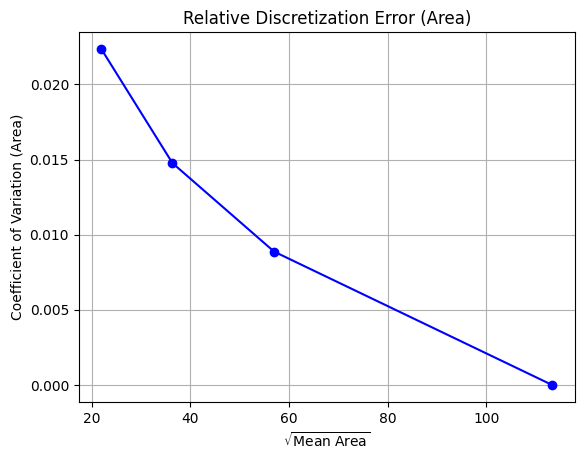

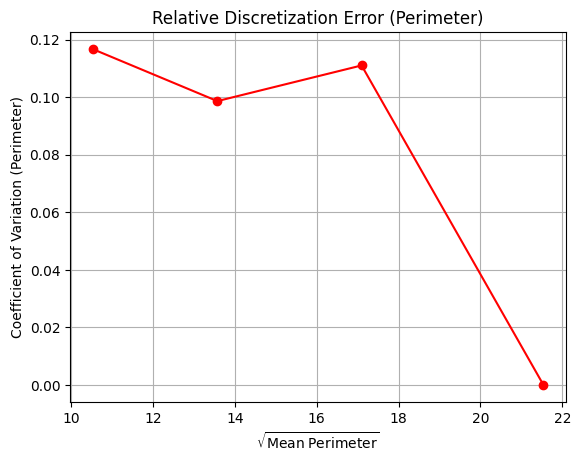

Relative discretization error plots generated and shown: area_relative_error.png and perimeter_relative_error.png


In [5]:
nBins = 256  # Number of histogram bins

apply_contrast_stretch = False
remove_edge_objects = True
apply_denoising = False

max_fg_fraction = 0.4          # Expected max fraction of foreground
fixed_threshold_value = 100    # Fixed threshold value (adjust as needed)

outdir = "results_21_22"
os.makedirs(outdir, exist_ok=True)

processing_pipeline(series_A, outdir, nBins, apply_contrast_stretch, remove_edge_objects, max_fg_fraction,
                    fixed_threshold_value, apply_denoising)

# Part 2.3


Processing rect1c.tif for measurements...
Original intensity range: min = 0  max = 255
Histogram saved as results_23/ksize_(9, 7)_kshape_elliptic/rect1c.tif_hist.png
Applying denoissing using mean filter
Denoised image saved as results_23/ksize_(9, 7)_kshape_elliptic/rect1c.tif_denoised_ksize_(9, 7)_kshape_elliptic.png
IsodataThreshold succeeded.
OtsuThreshold succeeded.
FixedThreshold (100) succeeded.
Method Isodata: unique values = [False  True], fg fraction = 0.801
Binary image (Isodata) saved as results_23/ksize_(9, 7)_kshape_elliptic/rect1c.tif_Isodata_binary.png
Method Otsu: unique values = [False  True], fg fraction = 0.801
Binary image (Otsu) saved as results_23/ksize_(9, 7)_kshape_elliptic/rect1c.tif_Otsu_binary.png
Method Fixed: unique values = [False  True], fg fraction = 0.877
Binary image (Fixed) saved as results_23/ksize_(9, 7)_kshape_elliptic/rect1c.tif_Fixed_binary.png
Chosen threshold method: Isodata with fg fraction 0.801
Chosen method initial fg fraction: 0.801
Fore

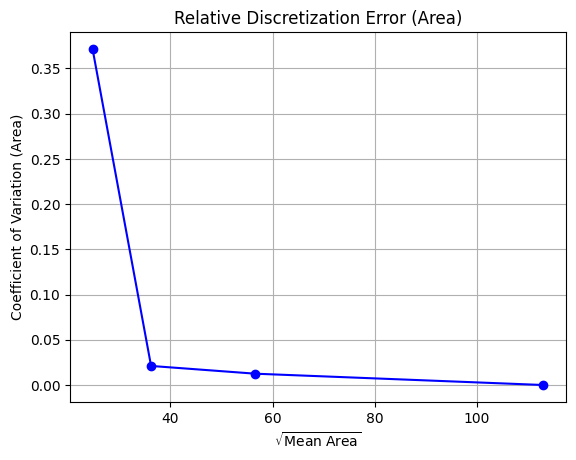

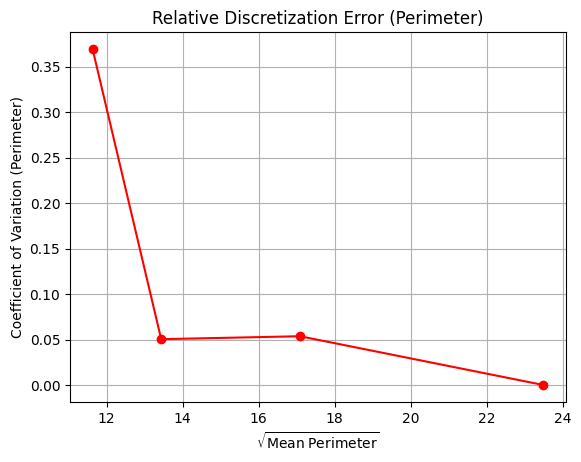

Relative discretization error plots generated and shown: area_relative_error.png and perimeter_relative_error.png


In [14]:
nBins = 256  # Number of histogram bins

apply_contrast_stretch = False
remove_edge_objects = True
apply_denoising = True
kernel_size = 5
kernel_shape = 'elliptic'

max_fg_fraction = 0.4          # Expected max fraction of foreground
fixed_threshold_value = 100    # Fixed threshold value (adjust as needed)

for series in [series_C]:
    # kernel size of the median filter, together with the structering element size of the opening/closing
    for kernel_size in [(9, 7)]:
        for kernel_shape in ['elliptic']:
            outdir = f"results_23/ksize_{kernel_size}_kshape_{kernel_shape}"
            os.makedirs(outdir, exist_ok=True)

            processing_pipeline(series, outdir, nBins, apply_contrast_stretch, remove_edge_objects, max_fg_fraction,
                            fixed_threshold_value, apply_denoising, kernel_size, kernel_shape)